#### Dependencies

In [12]:
!uv pip install -e "../.[performance]"
# import mct

Using Python 3.11.14 environment at: /Users/zickers/Research/krastanov_lab/open-source-projects/MCT/.venv
Resolved 7 packages in 13ms                                          
   Building numba==0.63.1                                              
   Building numba==0.63.1                                      
   Building llvmlite==0.46.0
   Building numba==0.63.1                                      
   Building llvmlite==0.46.0
   Building mct @ file:///Users/zickers/Research/krastanov_lab/open-source-proje
   Building numba==0.63.1                                      
   Building llvmlite==0.46.0
   Building mct @ file:///Users/zickers/Research/krastanov_lab/open-source-proje
   Building numba==0.63.1                                      
   Building llvmlite==0.46.0
   Building mct @ file:///Users/zickers/Research/krastanov_lab/open-source-proje
   Building numba==0.63.1                                      
   Building llvmlite==0.46.0
   Building mct @ file:///Users/zickers/Rese

# Amplitude Damping demo

$$E_0(\lambda) = \begin{pmatrix} 1 & 0 \\ 0 & \sqrt{1-\lambda} \end{pmatrix}, \quad E_1(\lambda) = \begin{pmatrix} 0 & \sqrt{\lambda} \\ 0 & 0 \end{pmatrix}$$

In [13]:
import mct
from mct import apply_channel, probability_symbol, get_density_basis, to_bell_basis, lmatrix, apply_channel_basis, run_markov_experiment, transition_matrix_from_sympy
import sympy as sp

# kraus ops
λ, assumptions = probability_symbol('λ')
E0 = sp.Matrix([[1, 0], [0, sp.sqrt(1 - λ)]])
E1 = sp.Matrix([[0, sp.sqrt(λ)], [0, 0]])

# # get computational basis
basis_states = get_density_basis(2) # 2qubit
print("State 1")
display(lmatrix(basis_states[1]))

State 1


<IPython.core.display.Math object>

In [14]:

rho_finals = apply_channel_basis(basis_states, [E0, E1], symbols=[λ], assumptions=assumptions)


State 0


<IPython.core.display.Math object>

State 1


<IPython.core.display.Math object>

State 2


<IPython.core.display.Math object>

State 3


<IPython.core.display.Math object>

In [15]:
# Kraus ops with substituted value
# dt = gate_time
dt = 0.5
# dt = 0.1 # μs
t1 = 200 # μs
# use a longer gate for faster decay 
# gate_time = 0.2 # μs

# lambda_val = lambda1_from_t1_gate_time(t1, dt)
lambda_val = 1 - sp.exp(-dt / t1)

kraus_ops = [E0.subs(λ, lambda_val), E1.subs(λ, lambda_val)]
# print(f"Using λ = {lambda_val.evalf()}")
display(lmatrix(kraus_ops))

<IPython.core.display.Math object>

In [16]:

# amplitude damping, computational basis, starting from state 11 (4)

experiment_name = "Amplitude damping (computational basis)"
initial_state = 4
n_trajectories = 9000
keep_traj = 100

total_time = 1000  # μs - target simulation time
steps = int(total_time / dt)

print(f"Total simulation time: {total_time} μs")
print(f"Number of steps: {steps}")
print(f"λ value: {lambda_val}")
print(f"dt: {dt} μs")
# print(f"T1 time: {t1} μs")

# Compute analytical transition matrix from density matrices (exact, no sampling needed)
trans_matrix = transition_matrix_from_sympy(rho_finals, lambda_val)
print(trans_matrix)

Total simulation time: 1000 μs
Number of steps: 2000
λ value: 0.00249687760253992
dt: 0.5 μs
[[1.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [2.49687760e-03 9.97503122e-01 0.00000000e+00 0.00000000e+00]
 [2.49687760e-03 0.00000000e+00 9.97503122e-01 0.00000000e+00]
 [6.23439776e-06 2.49064320e-03 2.49064320e-03 9.95012479e-01]]


Plot saved to: plots/amplitude_damping_comp_basis_state11.png
Simulation completed in 20.40s (0.9M transitions/s)
Asymptotic populations: [9.76936270e-01 1.25666390e-02 1.02668329e-02 2.30257689e-04]
Plot saved to: plots/amplitude_damping_comp_basis_state11_analytical_comparison.png


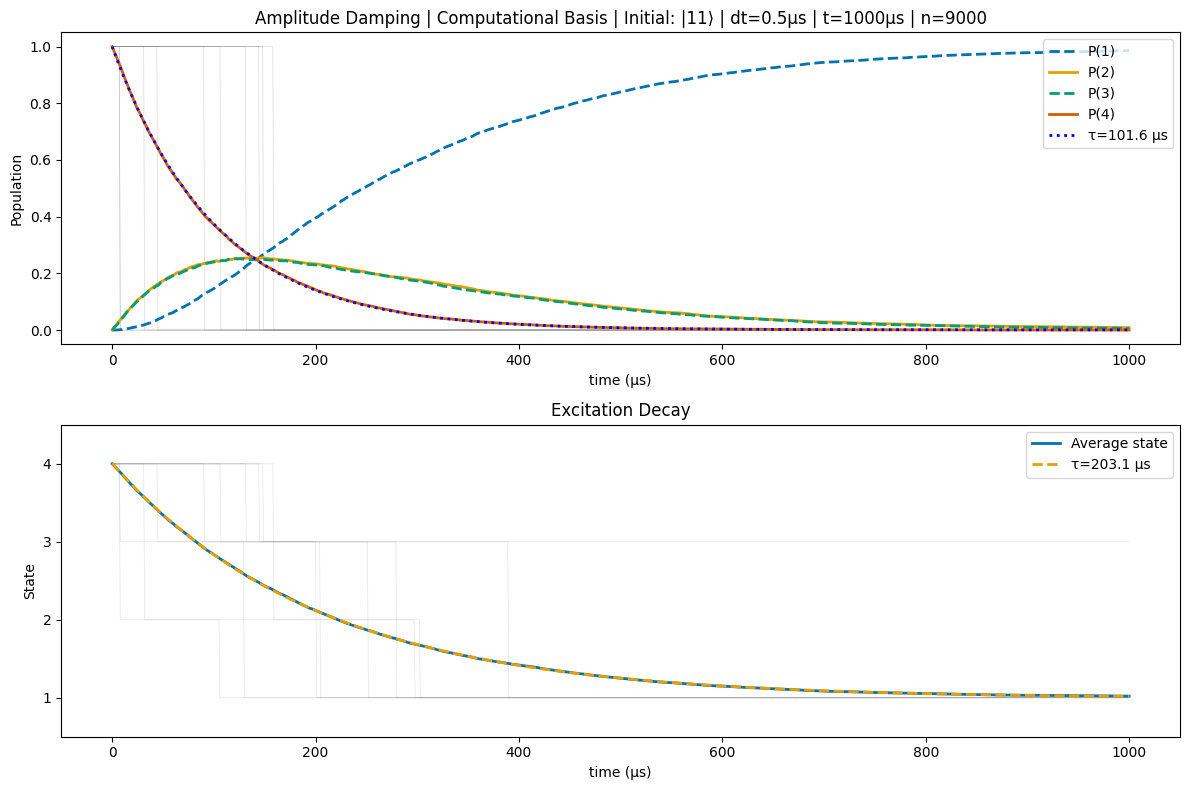

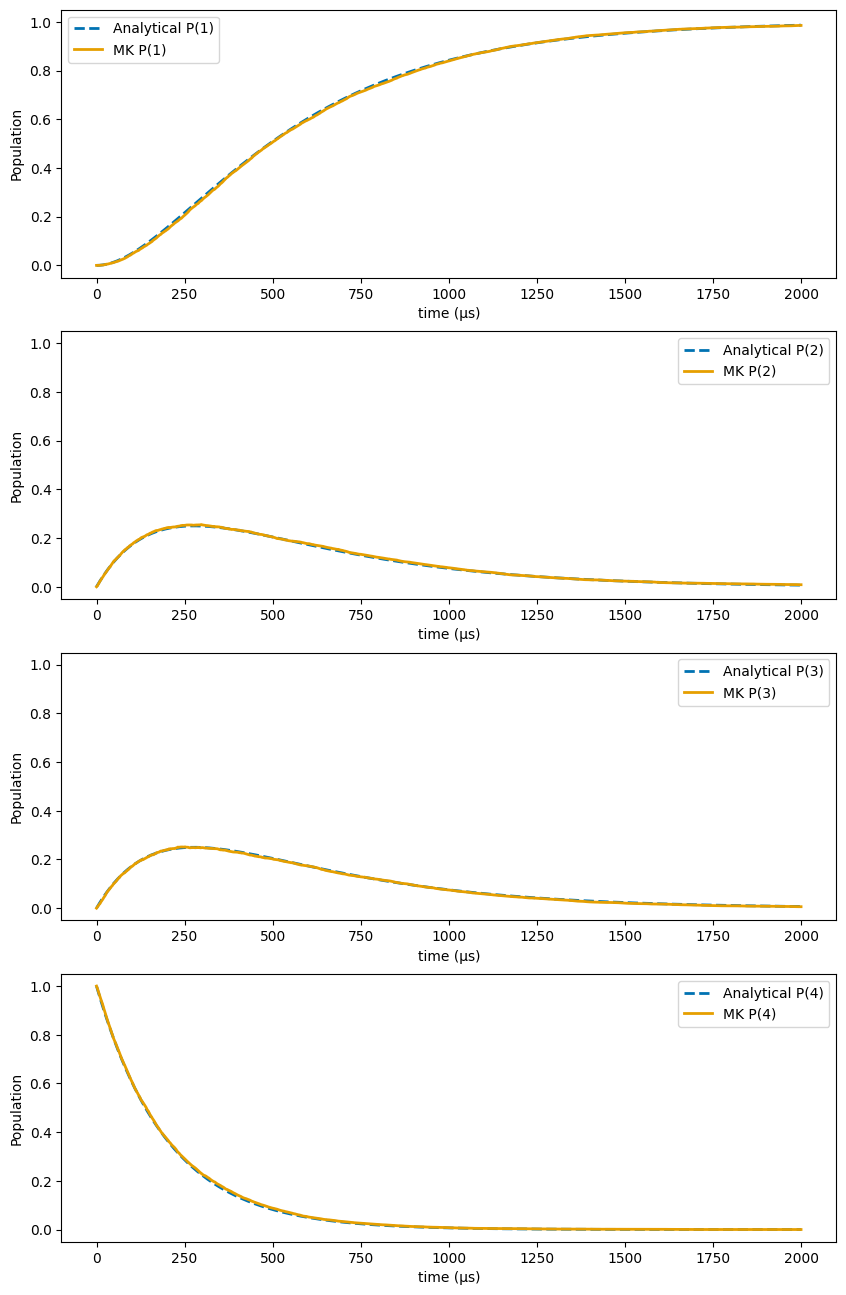

In [17]:

# Descriptive plot name and save path
plot_name = f"Amplitude Damping | Computational Basis | Initial: |11⟩ | dt={dt}μs | t={total_time}μs | n={n_trajectories}"
save_file = "plots/amplitude_damping_comp_basis_state11.png"

kept_trajs, pop_history, asymptotic_pops = run_markov_experiment(
    name=plot_name,
    initial_state=initial_state,
    dt=dt,
    steps=steps,
    n_trajectories=n_trajectories,
    keep_traj=keep_traj,
    fit_state=initial_state,  # fit decay of initial state
    state_count=4,
    transition_matrix=trans_matrix,  # Use analytical matrix
    save_path=save_file,
    # Analytical comparison
    compare_to_analytical_kraus=kraus_ops,
    analytical_init_state=basis_states[initial_state-1],
    analytical_pts=steps,
    analytical_symbols={λ: lambda_val}
)


### Bell basis

In [18]:

# get computational basis
basis_states = get_density_basis(2,basis='comp', states='bell') # 2qubit
print("State 1")
for i in range(len(basis_states)):
    display(lmatrix(basis_states[i]))

State 1


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [19]:

rho_finals = apply_channel_basis(basis_states, [E0, E1], symbols=[λ], assumptions=assumptions)


State 0


<IPython.core.display.Math object>

State 1


<IPython.core.display.Math object>

State 2


<IPython.core.display.Math object>

State 3


<IPython.core.display.Math object>

In [20]:
# Go into bell basis
from mct import to_bell_basis
rho_finals_bell = [to_bell_basis(sp.Matrix(rho)) for rho in rho_finals]
rho_finals_bell


⎡⎡      2                       2                   2               2          ↪
⎢⎢0.25⋅λ  - 0.5⋅λ + 0.25⋅(λ - 1)  + 0.75      0.25⋅λ  - 0.25⋅(λ - 1)  + 0.25   ↪
⎢⎢                                                                             ↪
⎢⎢          2               2                   2                       2      ↪
⎢⎢    0.25⋅λ  - 0.25⋅(λ - 1)  + 0.25      0.25⋅λ  + 0.5⋅λ + 0.25⋅(λ - 1)  - 0. ↪
⎢⎢                                                                             ↪
⎢⎢                  0                                       0                  ↪
⎢⎢                                                                             ↪
⎣⎣                  0                                       0                  ↪

↪                                 ⎤  ⎡      2                       2          ↪
↪           0              0      ⎥  ⎢0.25⋅λ  + 0.5⋅λ + 0.25⋅(λ - 1)  - 0.25   ↪
↪                                 ⎥  ⎢                                         ↪
↪                          

Total simulation time: 600 μs
Number of steps: 3000
λ value: 0.00199800133266692
dt: 0.2 μs
Plot saved to: plots/amplitude_damping_bell_basis_state11.png
Simulation completed in 20.31s (0.7M transitions/s)
Asymptotic populations: [0.25560865 0.23707654 0.25680998 0.25050483]


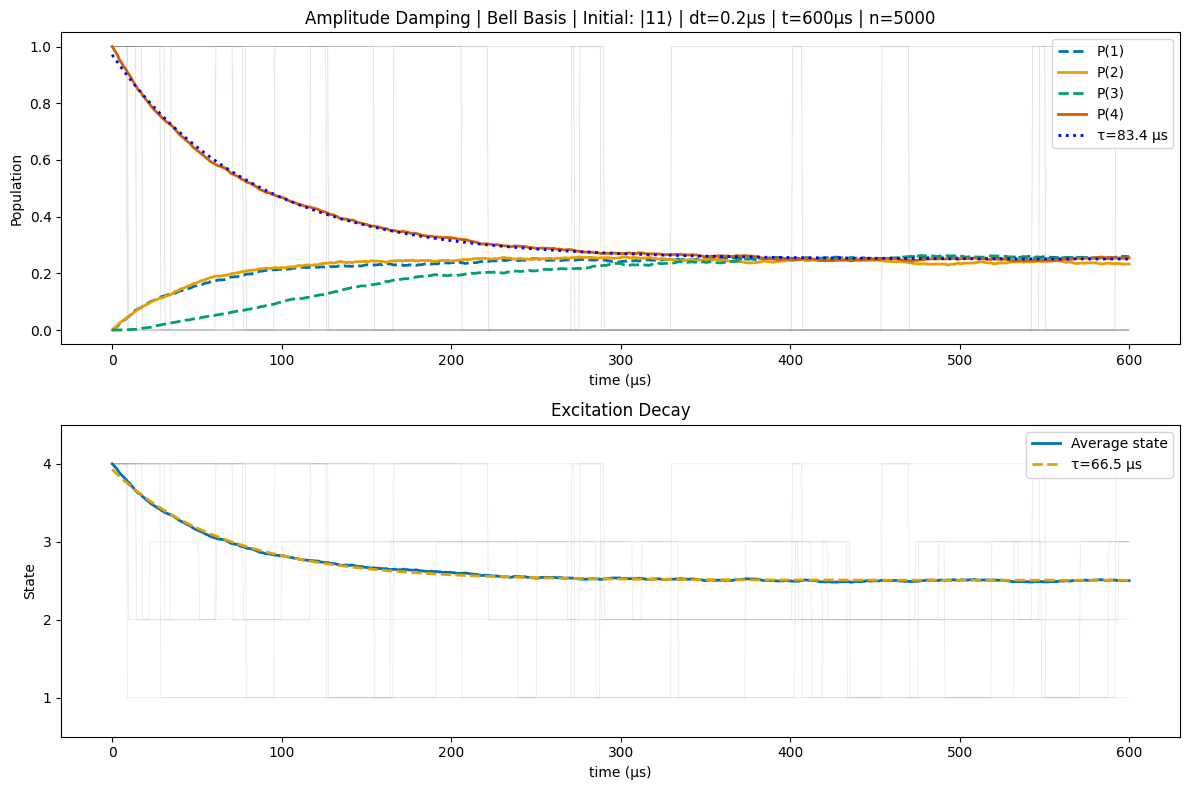

In [21]:

# amplitude damping, bell basis, starting from state 11 (4)

experiment_name = "Amplitude damping (bell basis)"
initial_state = 4
n_trajectories = 5000
keep_traj = 100
# dt = gate_time
dt = 0.2
# dt = 0.1 # μs
t1 = 100 # μs
# use a longer gate for faster decay 
# gate_time = 0.2 # μs

# lambda_val = lambda1_from_t1_gate_time(t1, dt)
lambda_val = 1 - sp.exp(-dt / t1)
# Work backwards from total time to calculate steps

total_time = 600  # μs - target simulation time
steps = int(total_time / dt)

print(f"Total simulation time: {total_time} μs")
print(f"Number of steps: {steps}")
print(f"λ value: {lambda_val}")
print(f"dt: {dt} μs")
# print(f"T1 time: {t1} μs")

# Compute analytical transition matrix from density matrices (exact, no sampling needed)
# trans_matrix = transition_matrix_from_sympy(rho_finals, lambda_val)
trans_matrix = transition_matrix_from_sympy(rho_finals_bell, lambda_val)

# Descriptive plot name and save path
plot_name = f"Amplitude Damping | Bell Basis | Initial: |11⟩ | dt={dt}μs | t={total_time}μs | n={n_trajectories}"
save_file = "plots/amplitude_damping_bell_basis_state11.png"

kept_trajs, pop_history, asymptotic_pops = run_markov_experiment(
    name=plot_name,
    initial_state=initial_state,
    dt=dt,
    steps=steps,
    n_trajectories=n_trajectories,
    keep_traj=keep_traj,
    fit_state=initial_state,  # fit decay of initial state
    state_count=4,
    transition_matrix=trans_matrix,  # Use analytical matrix
    save_path=save_file,
)
